<div align='center'><h2>Signature Assignment</h2></div>

<h3>Library</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
    f1_score, roc_auc_score, average_precision_score)

from sklearn.metrics import roc_curve
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance


<h3>Importing Data</h3></div>

In [2]:
eshop=pd.read_csv('/Users/claudefortune/Desktop/eshop.csv')

<h3>Exploratory Annalys: Part 1</h3>

In [3]:
print("Dataset shape:", eshop.shape)

print("\nColumn names:")
print(eshop.columns.tolist())

print("\nData types:")
print(eshop.dtypes)

print("\nFirst five rows:")
display(eshop.head())

Dataset shape: (12330, 18)

Column names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

First fi

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<h4>Missing Values</h4>

In [4]:

# MISSING VALUES
missing_values = eshop.isnull().sum()

print("Missing values by variable:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values by variable:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total missing values: 0


<h4>Check identical rows</h4>

In [5]:

# IDENTICAL / DUPLICATE ROWS

duplicate_count = eshop.duplicated().sum()

print("Number of identical rows:", duplicate_count)
print("Percentage of dataset:",
      round((duplicate_count / len(eshop)) * 100, 2), "%")

Number of identical rows: 125
Percentage of dataset: 1.01 %


<h4>Examine the Revenue target</h4>

In [6]:

# 4. TARGET VARIABLE DISTRIBUTION

revenue_counts = eshop["Revenue"].value_counts()
revenue_percent = eshop["Revenue"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": revenue_counts,
    "Percentage": revenue_percent
})

print(target_summary)

         Count  Percentage
Revenue                   
False    10422   84.525547
True      1908   15.474453


<h4>Revenue class distribution</h4>

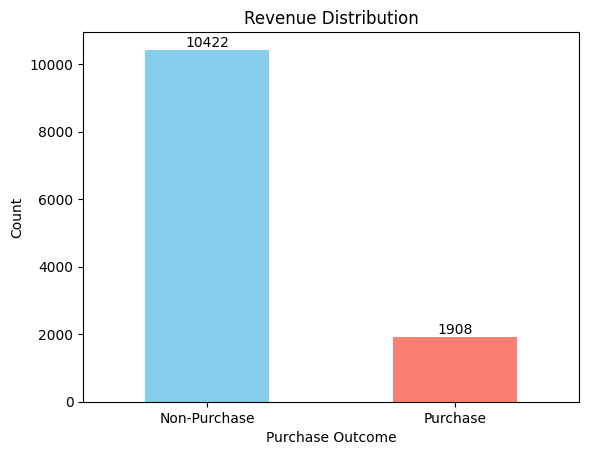

In [7]:
# Revenue Distribution with Counts

ax = eshop["Revenue"].value_counts().plot(
    kind="bar",
    color=["skyblue", "salmon"]
)

plt.title("Revenue Distribution")
plt.xlabel("Purchase Outcome")
plt.ylabel("Count")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Purchase", "Purchase"],
    rotation=0
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

<h4>One-hat-Encoding: for converting the variable</h4>

In [8]:
# Separate predictors and target
X = eshop.drop("Revenue", axis=1).copy()
y = eshop["Revenue"].astype(int)

# Convert Weekend from Boolean to binary
X["Weekend"] = X["Weekend"].astype(int)

# Variables treated as categorical
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

# One-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)


<h4>Train/spit</h4>

In [9]:
# 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.20,random_state=42, stratify=y)

# Fit only on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Apply the same transformation to test data
X_test_encoded = preprocessor.transform(X_test)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training observations: 9864
Testing observations: 2466

Training class distribution:
Revenue
0    0.845296
1    0.154704
Name: proportion, dtype: float64

Testing class distribution:
Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


<h4>Feature Engineering</h4>

In [10]:
# Feature Engineering

eshop["TotalPages"] = (
    eshop["Administrative"]
    + eshop["Informational"]
    + eshop["ProductRelated"]
)

eshop["TotalDuration"] = (
    eshop["Administrative_Duration"]
    + eshop["Informational_Duration"]
    + eshop["ProductRelated_Duration"]
)

eshop["AverageTimePerPage"] = (
    eshop["TotalDuration"] / eshop["TotalPages"]
)

eshop["ProductPageShare"] = (
    eshop["ProductRelated"] / eshop["TotalPages"]
)

# Replace undefined values caused by zero pages
eshop["AverageTimePerPage"] = eshop["AverageTimePerPage"].fillna(0)
eshop["ProductPageShare"] = eshop["ProductPageShare"].fillna(0)

eshop[
    ["TotalPages",
     "TotalDuration",
     "AverageTimePerPage",
     "ProductPageShare"]
].head()

,TotalPages,TotalDuration,AverageTimePerPage,ProductPageShare
0,1,0.000000,0.000000,1.0
1,2,64.000000,32.000000,1.0
2,1,0.000000,0.000000,1.0
3,2,2.666667,1.333333,1.0
4,10,627.500000,62.750000,1.0


<h4>Baline Random Forest</h4>

In [11]:

# Baseline Random Forest
rf_baseline = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_baseline.fit(X_train_encoded, y_train)

# Predictions
y_pred_baseline = rf_baseline.predict(X_test_encoded)
y_prob_baseline = rf_baseline.predict_proba(X_test_encoded)[:, 1]

# Performance metrics
print("Baseline Random Forest")
print("Accuracy:", round(accuracy_score(y_test, y_pred_baseline), 3))
print("Precision:", round(precision_score(y_test, y_pred_baseline), 3))
print("Recall:", round(recall_score(y_test, y_pred_baseline), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_baseline), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_baseline), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_baseline), 3))

Baseline Random Forest
Accuracy: 0.892
Precision: 0.634
Recall: 0.712
F1 Score: 0.671
ROC-AUC: 0.921
PR-AUC: 0.713


<h4>Random Forest with feature engineering</h4>

In [12]:

# Predictors with engineered features
X_eng = eshop.drop("Revenue", axis=1).copy()
y_eng = eshop["Revenue"].astype(int)

X_eng["Weekend"] = X_eng["Weekend"].astype(int)

# Use the SAME train/test observations as the baseline model
X_train_eng = X_eng.loc[X_train.index]
X_test_eng = X_eng.loc[X_test.index]

# Encode categorical variables
preprocessor_eng = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

X_train_eng_encoded = preprocessor_eng.fit_transform(X_train_eng)
X_test_eng_encoded = preprocessor_eng.transform(X_test_eng)

# Engineered-feature Random Forest
rf_engineered = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf_engineered.fit(X_train_eng_encoded, y_train)

# Predictions
y_pred_eng = rf_engineered.predict(X_test_eng_encoded)
y_prob_eng = rf_engineered.predict_proba(X_test_eng_encoded)[:, 1]

# Metrics
print("Engineered Random Forest")
print("Accuracy:", round(accuracy_score(y_test, y_pred_eng), 3))
print("Precision:", round(precision_score(y_test, y_pred_eng), 3))
print("Recall:", round(recall_score(y_test, y_pred_eng), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_eng), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_eng), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_eng), 3))

Engineered Random Forest
Accuracy: 0.893
Precision: 0.64
Recall: 0.699
F1 Score: 0.668
ROC-AUC: 0.919
PR-AUC: 0.714


<h4>Engineering features only Random Forest</h4>

In [13]:
# Engineered features only
engineered_features = [
    "TotalPages",
    "TotalDuration",
    "AverageTimePerPage",
    "ProductPageShare"
]

# Use the same training and testing observations
X_train_only_eng = eshop.loc[X_train.index, engineered_features]
X_test_only_eng = eshop.loc[X_test.index, engineered_features]

# Random Forest
rf_only_eng = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf_only_eng.fit(X_train_only_eng, y_train)

# Predictions
y_pred_only_eng = rf_only_eng.predict(X_test_only_eng)
y_prob_only_eng = rf_only_eng.predict_proba(X_test_only_eng)[:, 1]

# Metrics
print("Engineered Features Only Random Forest")
print("Accuracy:", round(accuracy_score(y_test, y_pred_only_eng), 3))
print("Precision:", round(precision_score(y_test, y_pred_only_eng), 3))
print("Recall:", round(recall_score(y_test, y_pred_only_eng), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_only_eng), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_only_eng), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_only_eng), 3))

Engineered Features Only Random Forest
Accuracy: 0.754
Precision: 0.243
Recall: 0.277
F1 Score: 0.259
ROC-AUC: 0.65
PR-AUC: 0.231


<h4>Comparison Model</h4>

In [14]:
results = pd.DataFrame({
    "Model": [
        "Original Features",
        "Engineered Features Only",
        "Original + Engineered Features"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_only_eng),
        accuracy_score(y_test, y_pred_eng)
    ],

    "Precision": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_only_eng),
        precision_score(y_test, y_pred_eng)
    ],

    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_only_eng),
        recall_score(y_test, y_pred_eng)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_only_eng),
        f1_score(y_test, y_pred_eng)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_baseline),
        roc_auc_score(y_test, y_prob_only_eng),
        roc_auc_score(y_test, y_prob_eng)
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob_baseline),
        average_precision_score(y_test, y_prob_only_eng),
        average_precision_score(y_test, y_prob_eng)
    ]
})

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Original Features,0.892,0.634,0.712,0.671,0.921,0.713
1,Engineered Features Only,0.754,0.243,0.277,0.259,0.650,0.231
2,Original + Engineered Features,0.893,0.640,0.699,0.668,0.919,0.714


<h4>Curve Comparison

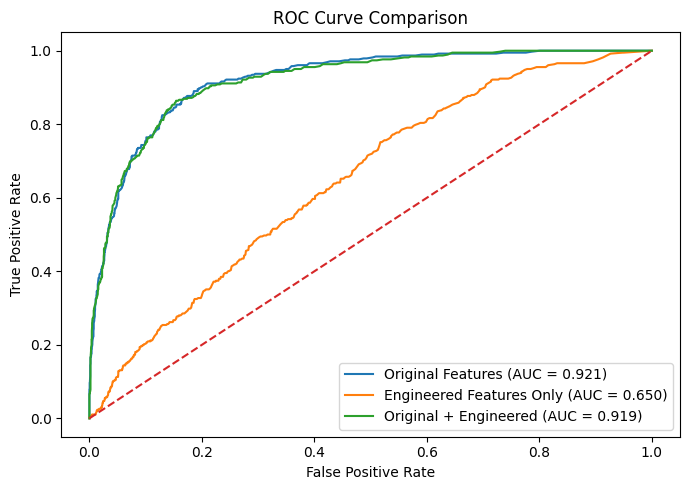

In [15]:

# ROC values
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_baseline)
fpr_only, tpr_only, _ = roc_curve(y_test, y_prob_only_eng)
fpr_eng, tpr_eng, _ = roc_curve(y_test, y_prob_eng)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Original Features (AUC = {roc_auc_score(y_test, y_prob_baseline):.3f})"
)

plt.plot(
    fpr_only,
    tpr_only,
    label=f"Engineered Features Only (AUC = {roc_auc_score(y_test, y_prob_only_eng):.3f})"
)

plt.plot(
    fpr_eng,
    tpr_eng,
    label=f"Original + Engineered (AUC = {roc_auc_score(y_test, y_prob_eng):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

<h4>Precision-Recall curve for models</h4>

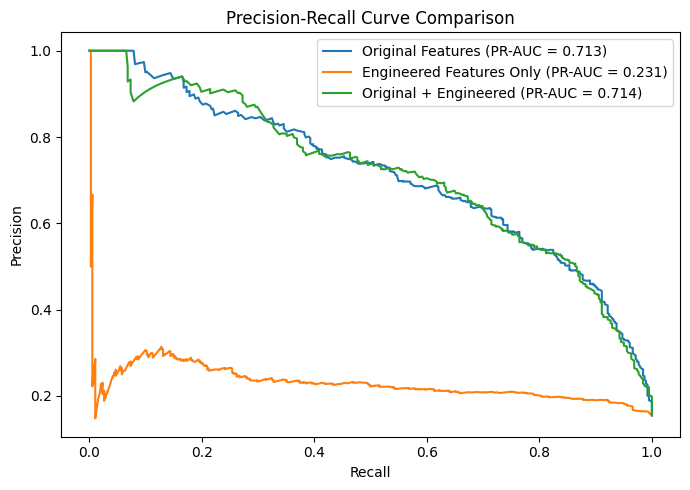

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_base, recall_base, _ = precision_recall_curve(
    y_test, y_prob_baseline
)

precision_only, recall_only, _ = precision_recall_curve(
    y_test, y_prob_only_eng
)

precision_eng, recall_eng, _ = precision_recall_curve(
    y_test, y_prob_eng
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_base,
    precision_base,
    label=f"Original Features (PR-AUC = {average_precision_score(y_test, y_prob_baseline):.3f})"
)

plt.plot(
    recall_only,
    precision_only,
    label=f"Engineered Features Only (PR-AUC = {average_precision_score(y_test, y_prob_only_eng):.3f})"
)

plt.plot(
    recall_eng,
    precision_eng,
    label=f"Original + Engineered (PR-AUC = {average_precision_score(y_test, y_prob_eng):.3f})"
)

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

<h4>feature importance</h4>

In [17]:
# Build the engineered Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_eng),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ))
])

# Fit the model
rf_pipeline.fit(X_train_eng, y_train)

# Permutation importance using PR-AUC
perm = permutation_importance(
    rf_pipeline,
    X_test_eng,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=42
)

# Create importance table
importance = pd.DataFrame({
    "Feature": X_test_eng.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance.round(4))


,Feature,Importance
8,PageValues,0.4730
10,Month,0.0425
7,ExitRates,0.0404
6,BounceRates,0.0254
14,TrafficType,0.0098
15,VisitorType,0.0093
16,Weekend,0.0046
19,AverageTimePerPage,0.0043
4,ProductRelated,0.0008
5,ProductRelated_Duration,0.0007


<h4>Graph of Permutation importance</h4>

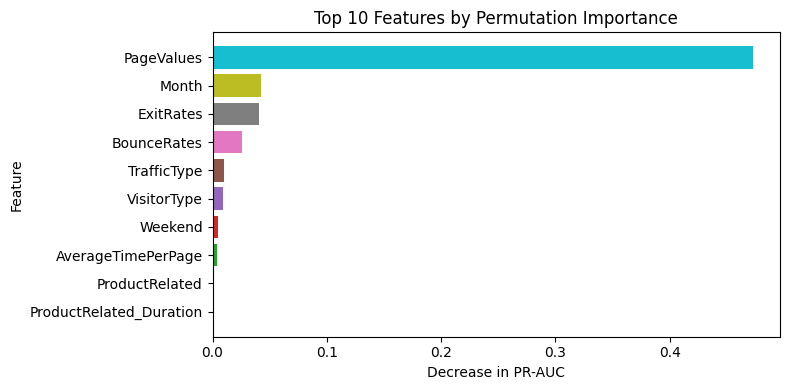

In [18]:
top10 = importance.head(10).sort_values("Importance")

colors = plt.cm.tab10(range(len(top10)))

plt.figure(figsize=(8, 4))

plt.barh(
    top10["Feature"],
    top10["Importance"],
    color=colors
)

plt.title("Top 10 Features by Permutation Importance")
plt.xlabel("Decrease in PR-AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<h4>Behavioral comparison for RQ1</h4>

In [19]:
# RQ1: Behavioral comparison

behavior_vars = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "TotalPages",
    "TotalDuration"
]

behavior_comparison = eshop.groupby("Revenue")[behavior_vars].mean().T

behavior_comparison.columns = ["Non-Purchase", "Purchase"]

display(behavior_comparison.round(3))

,Non-Purchase,Purchase
ProductRelated,28.715,48.210
ProductRelated_Duration,1069.988,1876.210
BounceRates,0.025,0.005
ExitRates,0.047,0.020
TotalPages,31.284,52.390
TotalDuration,1173.964,2053.304


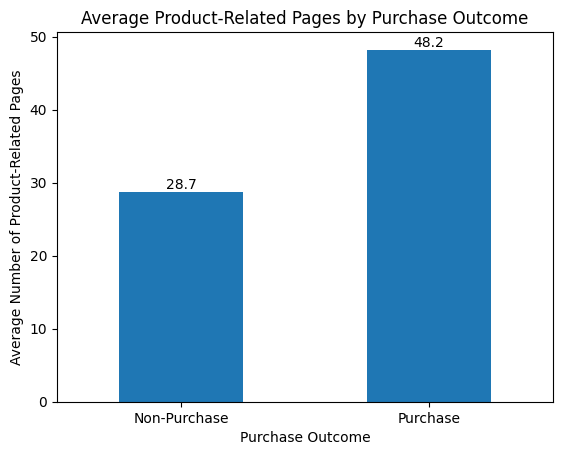

In [20]:
# Product-related pages by purchase outcome

ax = eshop.groupby("Revenue")["ProductRelated"].mean().plot(
    kind="bar"
)

plt.title("Average Product-Related Pages by Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Average Number of Product-Related Pages")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Purchase", "Purchase"],
    rotation=0
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.show()

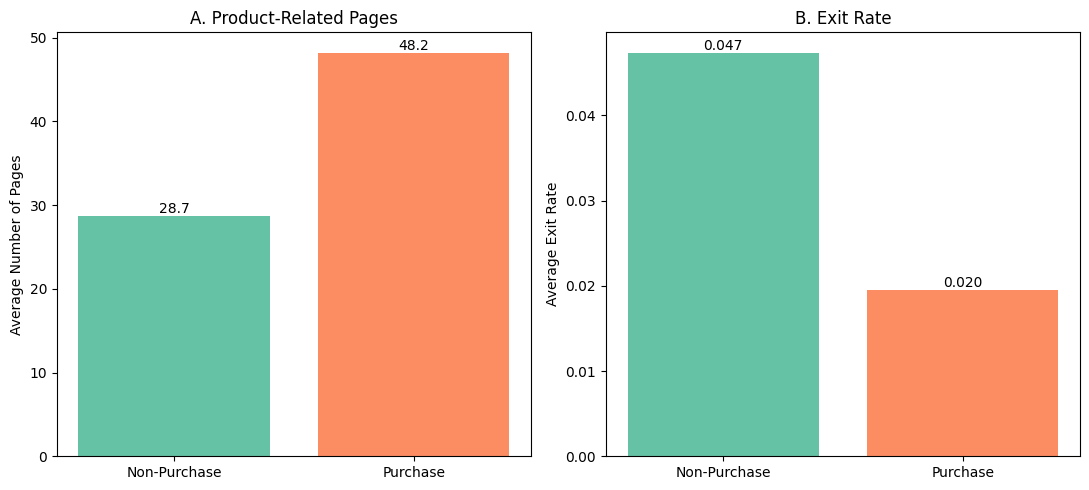

In [21]:
import matplotlib.pyplot as plt

# Average ProductRelated by purchase outcome
product_avg = eshop.groupby("Revenue")["ProductRelated"].mean()

# Average ExitRates by purchase outcome
exit_avg = eshop.groupby("Revenue")["ExitRates"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Panel A
bars1 = axes[0].bar(
    ["Non-Purchase", "Purchase"],
    product_avg.values,
    color=plt.cm.Set2(range(2))
)

axes[0].set_title("A. Product-Related Pages")
axes[0].set_ylabel("Average Number of Pages")

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom"
    )

# Panel B
bars2 = axes[1].bar(
    ["Non-Purchase", "Purchase"],
    exit_avg.values,
    color=plt.cm.Set2(range(2))
)

axes[1].set_title("B. Exit Rate")
axes[1].set_ylabel("Average Exit Rate")

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()